In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("data/customer_churn.csv")
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


np.int64(0)

In [4]:
df = df.dropna()
df = df.drop_duplicates()

In [5]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category').cat.codes

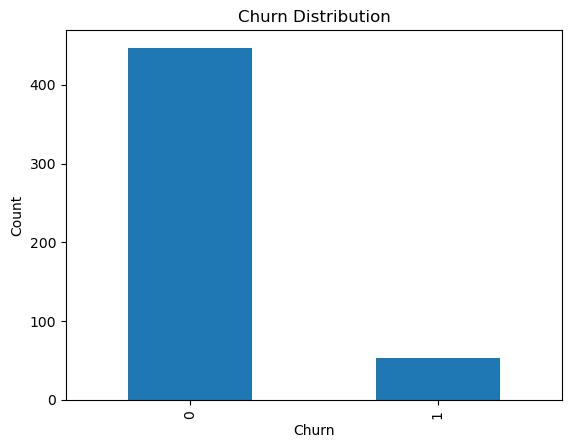

In [9]:
import matplotlib.pyplot as plt

df.columns = df.columns.str.lower().str.strip()

df['churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

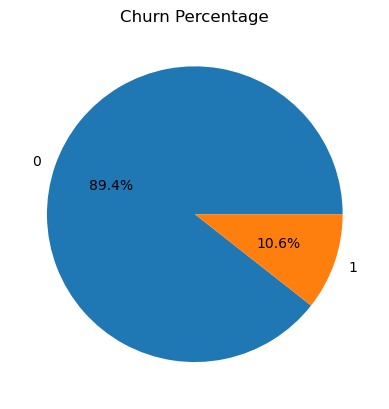

In [11]:
import matplotlib.pyplot as plt

if 'churn' in df.columns:
    df['churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title("Churn Percentage")
    plt.ylabel("")
    plt.show()
else:
    print("Column 'churn' not found")

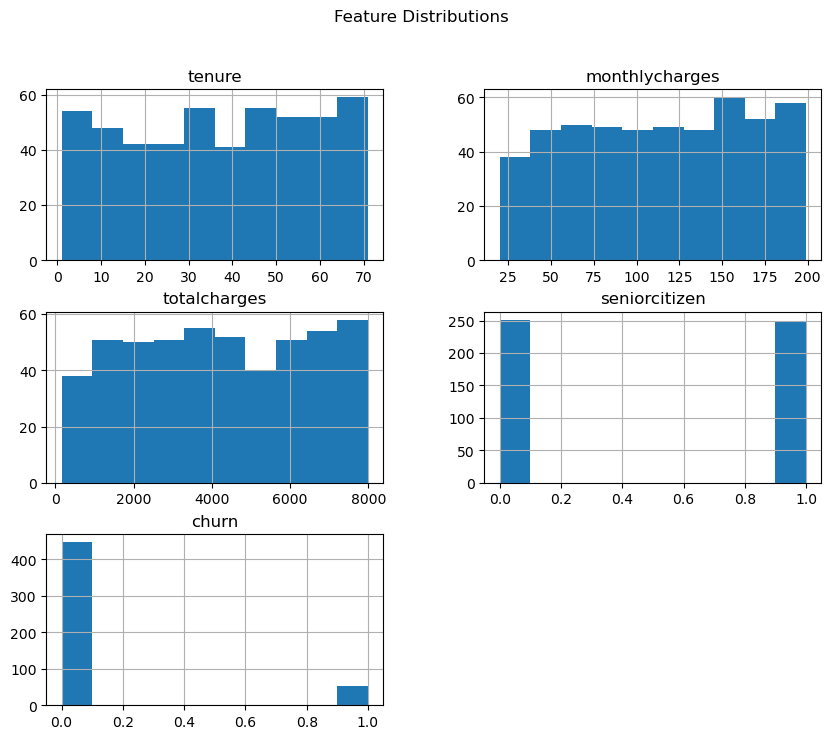

In [12]:
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

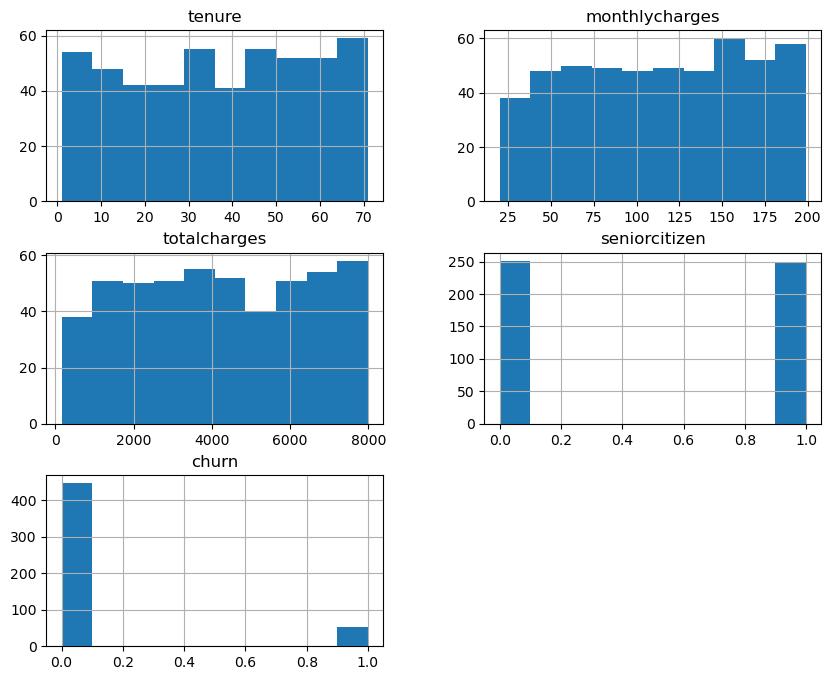

In [13]:
df.select_dtypes(include=['number']).hist(figsize=(10,8))
plt.show()

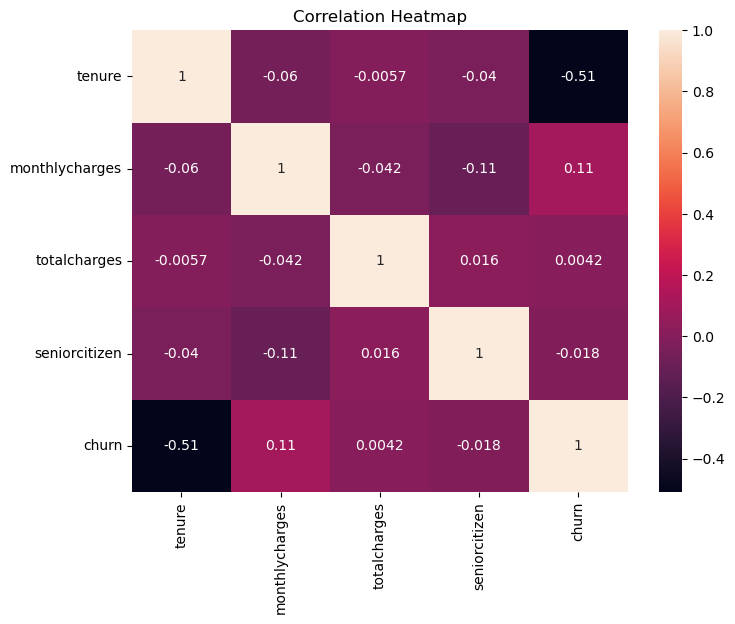

In [14]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

if not numeric_df.empty:
    plt.figure(figsize=(8,6))
    sns.heatmap(numeric_df.corr(), annot=True)
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("No numeric columns for correlation")

In [15]:
if 'churn' in df.columns:
    churn_rate = df['churn'].value_counts(normalize=True)*100
    print(churn_rate)
else:
    print("Column 'churn' not found")

churn
0    89.4
1    10.6
Name: proportion, dtype: float64


In [16]:
if 'churn' in df.columns:
    print(df.groupby('churn').mean(numeric_only=True))
else:
    print("Column 'churn' not found")

          tenure  monthlycharges  totalcharges  seniorcitizen
churn                                                        
0      40.152125      111.722595   4234.577181       0.501119
1       6.000000      129.773585   4265.754717       0.471698


In [17]:
if 'churn' in df.columns:
    numeric_df = df.select_dtypes(include=['number'])
    if 'churn' in numeric_df.columns:
        print(numeric_df.corr()['churn'].sort_values(ascending=False))
    else:
        print("Churn not numeric yet")
else:
    print("Column 'churn' not found")

churn             1.000000
monthlycharges    0.107381
totalcharges      0.004250
seniorcitizen    -0.018114
tenure           -0.509208
Name: churn, dtype: float64


In [18]:
if 'usage' in df.columns and 'churn' in df.columns:
    high_usage = df[df['usage'] > df['usage'].mean()]
    low_usage = df[df['usage'] <= df['usage'].mean()]

    print("High Usage Churn:", high_usage['churn'].mean())
    print("Low Usage Churn:", low_usage['churn'].mean())
else:
    print("Column 'usage' not found → skip this step")

Column 'usage' not found → skip this step


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

if 'churn' in df.columns:
    X = df.drop('churn', axis=1)
    y = df['churn']

    X = X.select_dtypes(include=['number'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
else:
    print("Column 'churn' not found")

Accuracy: 0.94


In [20]:
print(df.columns)
df.head()
df.info()

Index(['customerid', 'tenure', 'monthlycharges', 'totalcharges', 'contract',
       'paymentmethod', 'paperlessbilling', 'seniorcitizen', 'churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerid        500 non-null    object
 1   tenure            500 non-null    int64 
 2   monthlycharges    500 non-null    int64 
 3   totalcharges      500 non-null    int64 
 4   contract          500 non-null    object
 5   paymentmethod     500 non-null    object
 6   paperlessbilling  500 non-null    object
 7   seniorcitizen     500 non-null    int64 
 8   churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB
